# Part B — Analysis
## Market Sentiment vs Trader Behavior & Performance
---
**Questions to answer:**
1. Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?
2. Do traders change behavior based on sentiment?
3. Trader segmentation & key insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# Load processed data
merged = pd.read_csv('merged_data.csv', parse_dates=['date'])
daily_trader = pd.read_csv('daily_trader_metrics.csv', parse_dates=['date'])
daily_agg = pd.read_csv('daily_aggregate_metrics.csv', parse_dates=['date'])
print(f"Merged: {merged.shape}, Daily Trader: {daily_trader.shape}, Daily Agg: {daily_agg.shape}")

Merged: (211218, 25), Daily Trader: (2340, 20), Daily Agg: (479, 11)


## 1. Performance on Fear vs Greed Days
### Q: Does PnL, win rate, and drawdown differ based on sentiment?

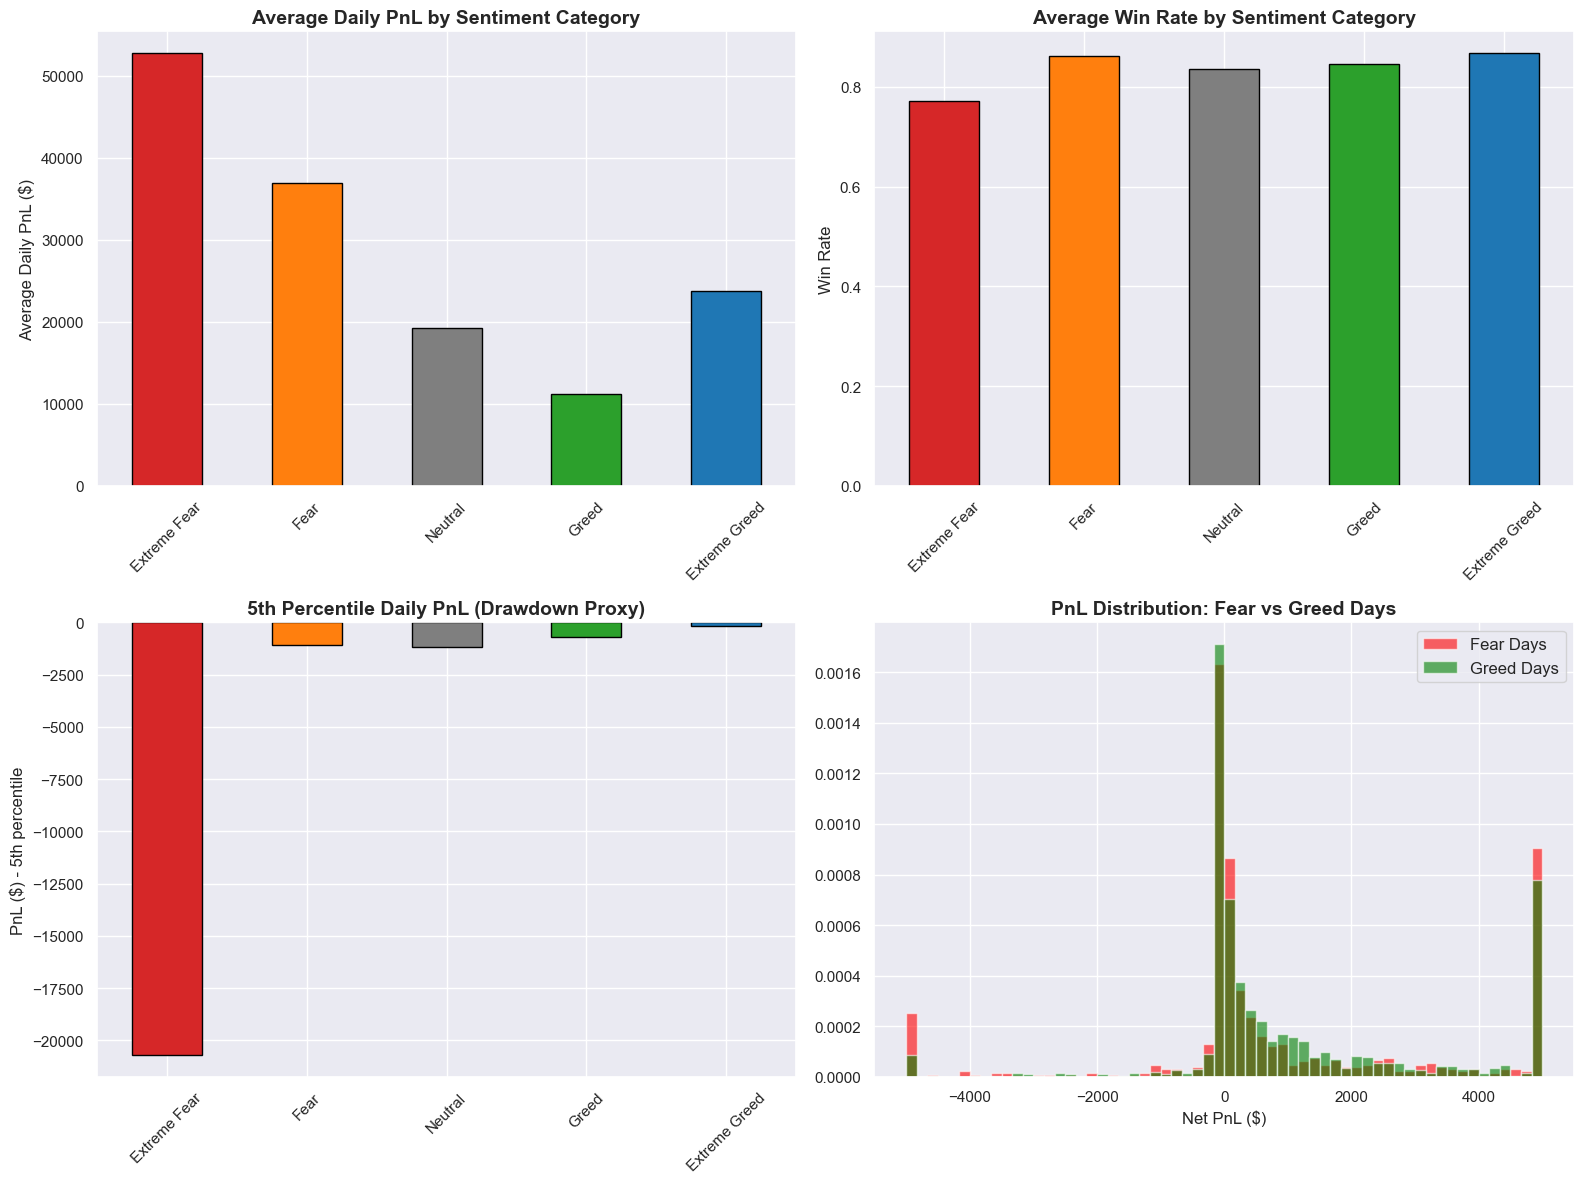


Mann-Whitney U test (Fear vs Greed PnL): U=434089, p=0.0162
Fear days avg PnL: $5037.87, Greed days avg PnL: $4067.44


In [2]:
# Binary sentiment: Fear (Extreme Fear + Fear) vs Greed (Extreme Greed + Greed)
sentiment_map = {
    'Extreme Fear': 'Fear', 'Fear': 'Fear', 
    'Neutral': 'Neutral',
    'Greed': 'Greed', 'Extreme Greed': 'Greed'
}
daily_trader['sentiment_binary'] = daily_trader['sentiment'].map(sentiment_map)
daily_agg['sentiment_binary'] = daily_agg['sentiment'].map(sentiment_map)

# PnL comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1) Average Daily PnL by Sentiment
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
colors = ['#d62728', '#ff7f0e', '#7f7f7f', '#2ca02c', '#1f77b4']
pnl_by_sent = daily_agg.groupby('sentiment')['total_pnl'].mean().reindex(order)
pnl_by_sent.plot.bar(ax=axes[0, 0], color=colors, edgecolor='black')
axes[0, 0].set_title('Average Daily PnL by Sentiment Category', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Average Daily PnL ($)')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2) Win Rate by Sentiment
wr_by_sent = daily_trader.groupby('sentiment')['win_rate'].mean().reindex(order)
wr_by_sent.plot.bar(ax=axes[0, 1], color=colors, edgecolor='black')
axes[0, 1].set_title('Average Win Rate by Sentiment Category', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Win Rate')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3) Drawdown Proxy: worst daily PnL by sentiment
drawdown = daily_trader.groupby('sentiment')['net_pnl'].quantile(0.05).reindex(order)
drawdown.plot.bar(ax=axes[1, 0], color=colors, edgecolor='black')
axes[1, 0].set_title('5th Percentile Daily PnL (Drawdown Proxy)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('PnL ($) - 5th percentile')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4) PnL distribution: Fear vs Greed
fear_pnl = daily_trader[daily_trader['sentiment_binary'] == 'Fear']['net_pnl']
greed_pnl = daily_trader[daily_trader['sentiment_binary'] == 'Greed']['net_pnl']
axes[1, 1].hist(fear_pnl.clip(-5000, 5000), bins=60, alpha=0.6, color='red', label='Fear Days', density=True)
axes[1, 1].hist(greed_pnl.clip(-5000, 5000), bins=60, alpha=0.6, color='green', label='Greed Days', density=True)
axes[1, 1].set_title('PnL Distribution: Fear vs Greed Days', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=12)
axes[1, 1].set_xlabel('Net PnL ($)')

plt.tight_layout()
plt.savefig('part_b_performance_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical test
t_stat, p_val = stats.mannwhitneyu(fear_pnl.dropna(), greed_pnl.dropna(), alternative='two-sided')
print(f"\nMann-Whitney U test (Fear vs Greed PnL): U={t_stat:.0f}, p={p_val:.4f}")
print(f"Fear days avg PnL: ${fear_pnl.mean():.2f}, Greed days avg PnL: ${greed_pnl.mean():.2f}")

## 2. Behavioral Changes by Sentiment
### Q: Do traders change trade frequency, leverage, long/short bias, position sizes?

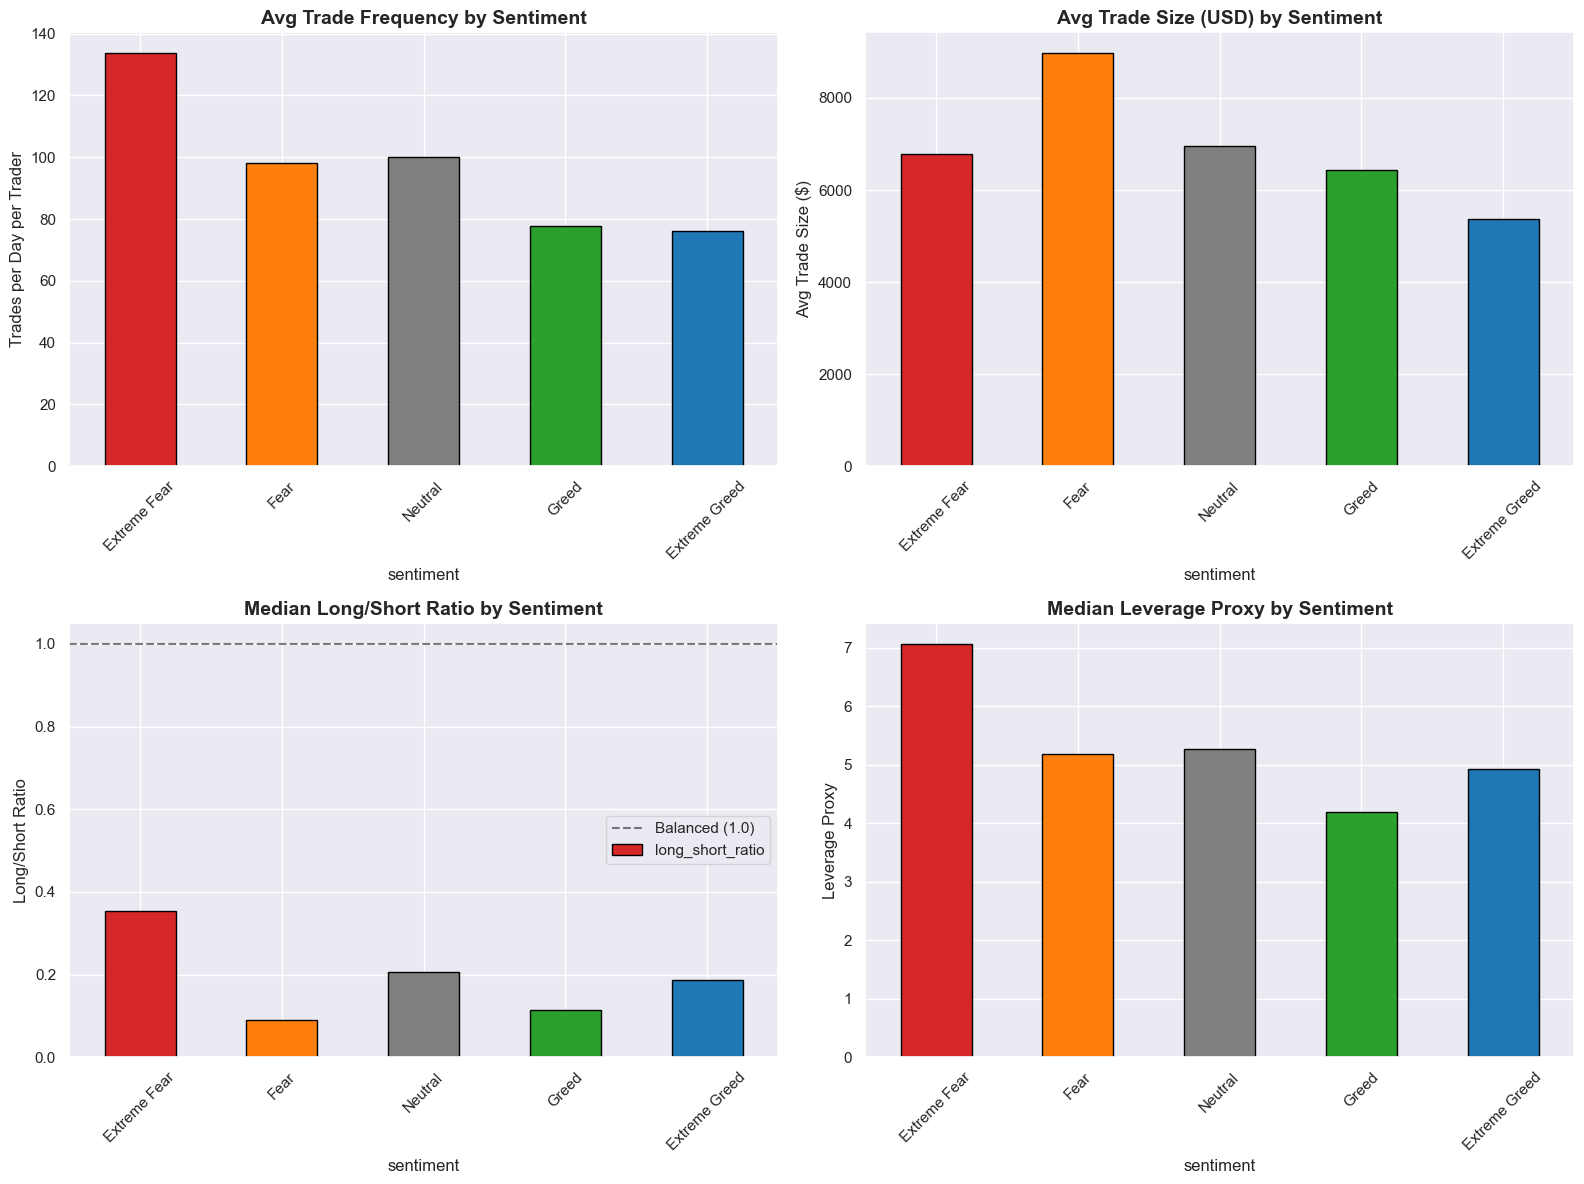


Behavior Summary by Sentiment:


,avg_trades,avg_size_usd,median_ls_ratio,median_leverage,avg_win_rate,avg_pnl
sentiment,,,,,,
Extreme Fear,133.750,6773.464,0.355,7.065,0.772,4470.135
Fear,98.154,8975.929,0.090,5.193,0.862,5182.061
Neutral,100.229,6963.695,0.205,5.269,0.836,3333.900
Greed,77.628,6427.867,0.113,4.191,0.846,3220.726
Extreme Greed,76.030,5371.637,0.188,4.936,0.868,5110.534


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1) Trade Frequency by Sentiment
tf = daily_trader.groupby('sentiment')['total_trades'].mean().reindex(order)
tf.plot.bar(ax=axes[0, 0], color=colors, edgecolor='black')
axes[0, 0].set_title('Avg Trade Frequency by Sentiment', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Trades per Day per Trader')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2) Average Trade Size by Sentiment
ts = daily_trader.groupby('sentiment')['avg_trade_size_usd'].mean().reindex(order)
ts.plot.bar(ax=axes[0, 1], color=colors, edgecolor='black')
axes[0, 1].set_title('Avg Trade Size (USD) by Sentiment', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Avg Trade Size ($)')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3) Long/Short Ratio by Sentiment
ls = daily_trader.groupby('sentiment')['long_short_ratio'].median().reindex(order)
ls.plot.bar(ax=axes[1, 0], color=colors, edgecolor='black')
axes[1, 0].axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='Balanced (1.0)')
axes[1, 0].set_title('Median Long/Short Ratio by Sentiment', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Long/Short Ratio')
axes[1, 0].legend()
axes[1, 0].tick_params(axis='x', rotation=45)

# 4) Leverage Proxy by Sentiment
lp = daily_trader.groupby('sentiment')['leverage_proxy'].median().reindex(order)
lp.plot.bar(ax=axes[1, 1], color=colors, edgecolor='black')
axes[1, 1].set_title('Median Leverage Proxy by Sentiment', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Leverage Proxy')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('part_b_behavior_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
behavior_summary = daily_trader.groupby('sentiment').agg(
    avg_trades=('total_trades', 'mean'),
    avg_size_usd=('avg_trade_size_usd', 'mean'),
    median_ls_ratio=('long_short_ratio', 'median'),
    median_leverage=('leverage_proxy', 'median'),
    avg_win_rate=('win_rate', 'mean'),
    avg_pnl=('net_pnl', 'mean'),
).reindex(order).round(3)
print("\nBehavior Summary by Sentiment:")
behavior_summary

## 3. Trader Segmentation
### Segment 1: High Leverage vs Low Leverage Traders
### Segment 2: Frequent vs Infrequent Traders
### Segment 3: Consistent Winners vs Inconsistent Traders

In [4]:
# ---- Trader-level aggregate stats ----
trader_stats = daily_trader.groupby('Account').agg(
    total_days=('date', 'nunique'),
    avg_daily_trades=('total_trades', 'mean'),
    total_pnl=('net_pnl', 'sum'),
    avg_pnl=('net_pnl', 'mean'),
    std_pnl=('net_pnl', 'std'),
    avg_win_rate=('win_rate', 'mean'),
    avg_leverage=('leverage_proxy', 'median'),
    avg_trade_size=('avg_trade_size_usd', 'mean'),
    total_volume=('total_volume_usd', 'sum'),
).reset_index()

# Sharpe-like consistency ratio
trader_stats['consistency'] = trader_stats['avg_pnl'] / trader_stats['std_pnl'].replace(0, np.nan)

# Segment 1: High vs Low Leverage
trader_stats['leverage_segment'] = pd.qcut(trader_stats['avg_leverage'].rank(method='first'), 
                                            2, labels=['Low Leverage', 'High Leverage'])

# Segment 2: Frequent vs Infrequent
trader_stats['frequency_segment'] = pd.qcut(trader_stats['avg_daily_trades'].rank(method='first'), 
                                             2, labels=['Infrequent', 'Frequent'])

# Segment 3: Consistent vs Inconsistent Winners
trader_stats['performance_segment'] = np.where(
    (trader_stats['avg_win_rate'] >= trader_stats['avg_win_rate'].median()) & 
    (trader_stats['consistency'] >= trader_stats['consistency'].median()),
    'Consistent Winner',
    np.where(trader_stats['total_pnl'] > 0, 'Inconsistent Winner', 'Net Loser')
)

print("Trader Segments:")
print(f"\nLeverage: {trader_stats['leverage_segment'].value_counts().to_dict()}")
print(f"Frequency: {trader_stats['frequency_segment'].value_counts().to_dict()}")
print(f"Performance: {trader_stats['performance_segment'].value_counts().to_dict()}")
trader_stats[['Account', 'total_days', 'avg_daily_trades', 'total_pnl', 'avg_win_rate', 
              'leverage_segment', 'frequency_segment', 'performance_segment']].head(10)

Trader Segments:

Leverage: {'Low Leverage': 16, 'High Leverage': 16}
Frequency: {'Infrequent': 16, 'Frequent': 16}
Performance: {'Inconsistent Winner': 15, 'Consistent Winner': 13, 'Net Loser': 4}


,Account,total_days,avg_daily_trades,total_pnl,avg_win_rate,leverage_segment,frequency_segment,performance_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,24,159.083333,1.592825e+06,0.770691,High Leverage,Frequent,Inconsistent Winner
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,52,140.000000,4.515548e+04,0.774669,High Leverage,Frequent,Inconsistent Winner
2,0x271b280974205ca63b716753467d5a371de622ab,12,317.416667,-7.971717e+04,0.729190,High Leverage,Frequent,Net Loser
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,162,82.166667,1.302464e+05,0.883499,High Leverage,Frequent,Inconsistent Winner
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,69,46.942029,1.655498e+05,0.761589,High Leverage,Infrequent,Inconsistent Winner
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,43,18.953488,-3.135067e+04,0.674228,Low Leverage,Infrequent,Net Loser
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,46,78.021739,1.299826e+04,0.831107,Low Leverage,Frequent,Inconsistent Winner
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,28,11.857143,5.331997e+04,1.000000,Low Leverage,Infrequent,Consistent Winner
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,20,19.150000,1.992376e+05,1.000000,Low Leverage,Infrequent,Consistent Winner
9,0x430f09841d65beb3f27765503d0f850b8bce7713,28,44.178571,4.157949e+05,1.000000,Low Leverage,Infrequent,Consistent Winner


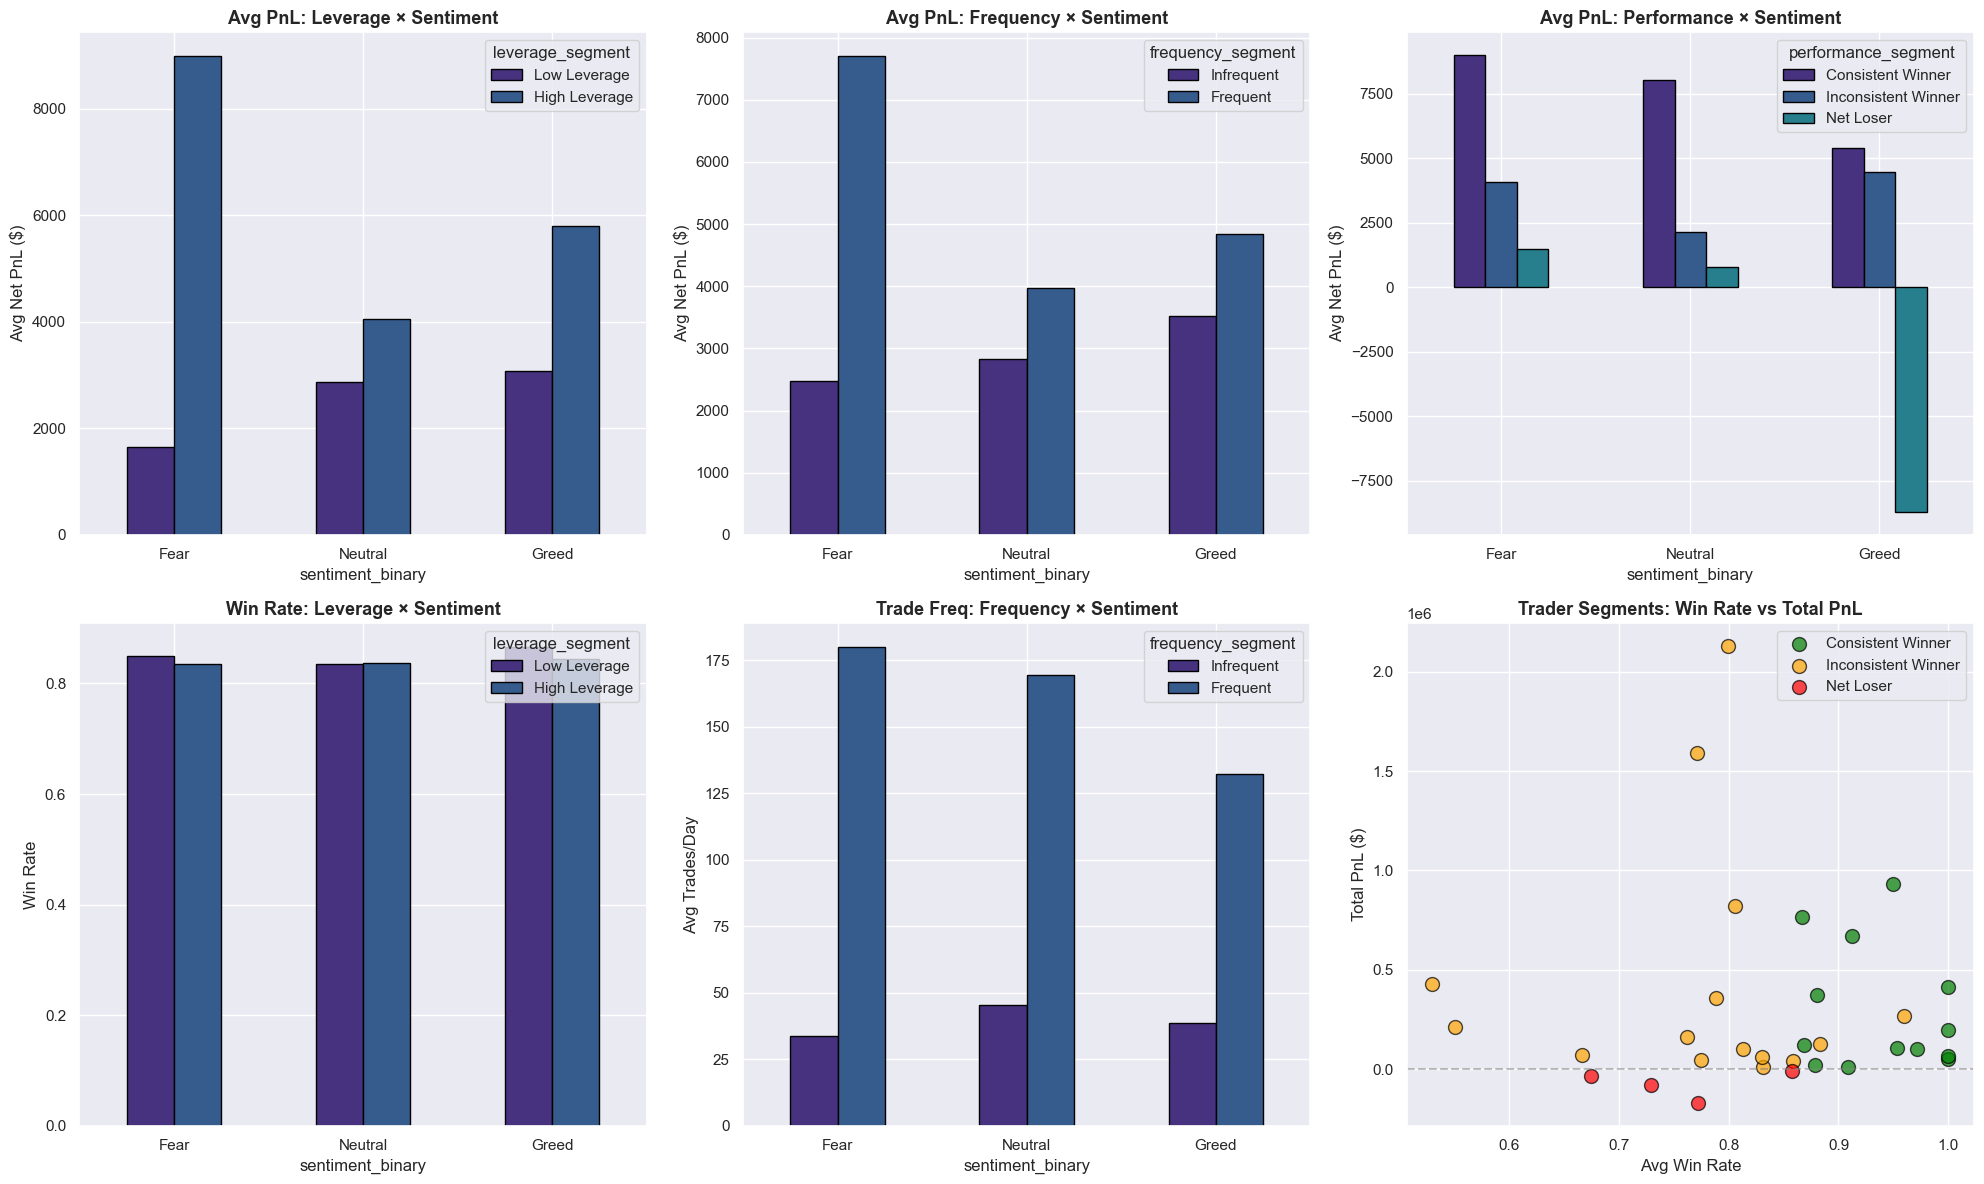

In [5]:
# ---- Segmentation Analysis Charts ----
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Merge segment info with daily data
daily_seg = daily_trader.merge(
    trader_stats[['Account', 'leverage_segment', 'frequency_segment', 'performance_segment']], 
    on='Account'
)

# Chart 1: PnL by Leverage Segment × Sentiment
seg_data = daily_seg.groupby(['sentiment_binary', 'leverage_segment'])['net_pnl'].mean().unstack()
seg_data.reindex(['Fear', 'Neutral', 'Greed']).plot.bar(ax=axes[0, 0], edgecolor='black')
axes[0, 0].set_title('Avg PnL: Leverage × Sentiment', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Avg Net PnL ($)')
axes[0, 0].tick_params(axis='x', rotation=0)

# Chart 2: PnL by Frequency Segment × Sentiment
seg_data2 = daily_seg.groupby(['sentiment_binary', 'frequency_segment'])['net_pnl'].mean().unstack()
seg_data2.reindex(['Fear', 'Neutral', 'Greed']).plot.bar(ax=axes[0, 1], edgecolor='black')
axes[0, 1].set_title('Avg PnL: Frequency × Sentiment', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Avg Net PnL ($)')
axes[0, 1].tick_params(axis='x', rotation=0)

# Chart 3: PnL by Performance Segment × Sentiment
seg_data3 = daily_seg.groupby(['sentiment_binary', 'performance_segment'])['net_pnl'].mean().unstack()
seg_data3.reindex(['Fear', 'Neutral', 'Greed']).plot.bar(ax=axes[0, 2], edgecolor='black')
axes[0, 2].set_title('Avg PnL: Performance × Sentiment', fontsize=13, fontweight='bold')
axes[0, 2].set_ylabel('Avg Net PnL ($)')
axes[0, 2].tick_params(axis='x', rotation=0)

# Chart 4: Win Rate by Leverage × Sentiment
seg_wr = daily_seg.groupby(['sentiment_binary', 'leverage_segment'])['win_rate'].mean().unstack()
seg_wr.reindex(['Fear', 'Neutral', 'Greed']).plot.bar(ax=axes[1, 0], edgecolor='black')
axes[1, 0].set_title('Win Rate: Leverage × Sentiment', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Win Rate')
axes[1, 0].tick_params(axis='x', rotation=0)

# Chart 5: Trade Frequency by Freq Segment × Sentiment
seg_tf = daily_seg.groupby(['sentiment_binary', 'frequency_segment'])['total_trades'].mean().unstack()
seg_tf.reindex(['Fear', 'Neutral', 'Greed']).plot.bar(ax=axes[1, 1], edgecolor='black')
axes[1, 1].set_title('Trade Freq: Frequency × Sentiment', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Avg Trades/Day')
axes[1, 1].tick_params(axis='x', rotation=0)

# Chart 6: Trader Stats Scatter
ax6 = axes[1, 2]
for seg, color in [('Consistent Winner', 'green'), ('Inconsistent Winner', 'orange'), ('Net Loser', 'red')]:
    mask = trader_stats['performance_segment'] == seg
    ax6.scatter(trader_stats[mask]['avg_win_rate'], trader_stats[mask]['total_pnl'],
                c=color, label=seg, alpha=0.7, s=100, edgecolor='black')
ax6.set_title('Trader Segments: Win Rate vs Total PnL', fontsize=13, fontweight='bold')
ax6.set_xlabel('Avg Win Rate')
ax6.set_ylabel('Total PnL ($)')
ax6.legend()
ax6.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('part_b_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Key Insights (with Evidence)

In [6]:
# ===== INSIGHT 1: Fear/Greed sentiment has measurable impact on PnL =====
print("=" * 70)
print("INSIGHT 1: Sentiment Impact on Performance")
print("=" * 70)
fear_stats = daily_agg[daily_agg['sentiment_binary'] == 'Fear']
greed_stats = daily_agg[daily_agg['sentiment_binary'] == 'Greed']
neutral_stats = daily_agg[daily_agg['sentiment_binary'] == 'Neutral']
print(f"Fear days   - Avg PnL: ${fear_stats['total_pnl'].mean():>12,.2f} | Avg Win Rate: {daily_trader[daily_trader['sentiment_binary']=='Fear']['win_rate'].mean():.3f}")
print(f"Neutral days- Avg PnL: ${neutral_stats['total_pnl'].mean():>12,.2f} | Avg Win Rate: {daily_trader[daily_trader['sentiment_binary']=='Neutral']['win_rate'].mean():.3f}")
print(f"Greed days  - Avg PnL: ${greed_stats['total_pnl'].mean():>12,.2f} | Avg Win Rate: {daily_trader[daily_trader['sentiment_binary']=='Greed']['win_rate'].mean():.3f}")

# ===== INSIGHT 2: Behavioral Shift =====
print("\n" + "=" * 70)
print("INSIGHT 2: Traders shift behavior during different sentiment regimes")
print("=" * 70)
for s in ['Fear', 'Neutral', 'Greed']:
    sub = daily_trader[daily_trader['sentiment_binary'] == s]
    print(f"{s:8s} | Avg Trades: {sub['total_trades'].mean():6.1f} | "
          f"Avg Size: ${sub['avg_trade_size_usd'].mean():>10,.2f} | "
          f"L/S Ratio: {sub['long_short_ratio'].median():.2f}")

# ===== INSIGHT 3: Segment-Specific Patterns =====
print("\n" + "=" * 70)
print("INSIGHT 3: Segment-specific response to sentiment")
print("=" * 70)
for seg_col in ['leverage_segment', 'frequency_segment', 'performance_segment']:
    print(f"\n--- {seg_col} ---")
    for seg_val in daily_seg[seg_col].unique():
        sub = daily_seg[daily_seg[seg_col] == seg_val]
        fear_pnl = sub[sub['sentiment_binary'] == 'Fear']['net_pnl'].mean()
        greed_pnl = sub[sub['sentiment_binary'] == 'Greed']['net_pnl'].mean()
        print(f"  {seg_val:25s} | Fear PnL: ${fear_pnl:>10,.2f} | Greed PnL: ${greed_pnl:>10,.2f}")

INSIGHT 1: Sentiment Impact on Performance
Fear days   - Avg PnL: $   39,012.05 | Avg Win Rate: 0.842
Neutral days- Avg PnL: $   19,297.32 | Avg Win Rate: 0.836
Greed days  - Avg PnL: $   15,847.88 | Avg Win Rate: 0.856

INSIGHT 2: Traders shift behavior during different sentiment regimes
Fear     | Avg Trades:  105.4 | Avg Size: $  8,529.86 | L/S Ratio: 0.17
Neutral  | Avg Trades:  100.2 | Avg Size: $  6,963.69 | L/S Ratio: 0.21
Greed    | Avg Trades:   76.9 | Avg Size: $  5,954.63 | L/S Ratio: 0.16

INSIGHT 3: Segment-specific response to sentiment

--- leverage_segment ---
  Low Leverage              | Fear PnL: $  1,645.25 | Greed PnL: $  3,080.34
  High Leverage             | Fear PnL: $  8,988.19 | Greed PnL: $  5,800.66

--- frequency_segment ---
  Infrequent                | Fear PnL: $  2,480.80 | Greed PnL: $  3,529.09
  Frequent                  | Fear PnL: $  7,700.67 | Greed PnL: $  4,843.06

--- performance_segment ---
  Net Loser                 | Fear PnL: $  1,466.97 |

In [7]:
# Save segment data for Part C
trader_stats.to_csv('trader_segments.csv', index=False)
daily_seg.to_csv('daily_segmented.csv', index=False)
print("Saved: trader_segments.csv, daily_segmented.csv")

Saved: trader_segments.csv, daily_segmented.csv
